In [13]:

import json
import numpy as np
import os
import pickle as pkl
from copy import deepcopy
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
# retrieve sample number
cnts = []
cnts_sum = {'normal':0,'jigsaw1':0,'jigsaw2':0,'jigsaw3':0,
                     'blur1':0,'blur2':0,'blur3':0,'blur4':0,'blur5':0,
                     'amount1':0, 'amount2':0,'amount3':0,'amount4':0,'amount5':0}
for rule_no in [0,2,4]:
    image_dir = '../fribble_v2/split_for_models/rule_{}.pkl'.format(rule_no)
    with open(image_dir,'rb') as f:
        imgs = pkl.load(f)

    cnt = {'normal':0,'jigsaw1':0,'jigsaw2':0,'jigsaw3':0,
                     'blur1':0,'blur2':0,'blur3':0,'blur4':0,'blur5':0,
                     'amount1':0, 'amount2':0,'amount3':0,'amount4':0,'amount5':0}
    for img in imgs['test']:
    #     print(img)
        cond = img.split('/')[2].split('_')[-1]
        cond = 'normal' if cond[-1] == '0' else cond 
        cnt[cond] += 1
        cnts_sum[cond] += 1
    cnts.append(cnt)


In [8]:
seco_large = ["normal1: 0.4294244050979614	jigsaw1: 0.3680632412433624	jigsaw2: 0.33547013998031616	jigsaw3: 0.34275439381599426	blur1: 0.4125346541404724	blur2: 0.40652576088905334	blur3: 0.42072412371635437	blur4: 0.32398998737335205	blur5: 0.3110921382904053	amount1: 0.3281081020832062	amount2: 0.3564521074295044	amount3: 0.30954205989837646	amount4: 0.38219350576400757	amount5: 0.3847380578517914",
                "normal1: 0.575452446937561	jigsaw1: 0.4328611493110657	jigsaw2: 0.35507869720458984	jigsaw3: 0.11016476899385452	blur1: 0.5435380935668945	blur2: 0.5060440301895142	blur3: 0.3742679953575134	blur4: 0.2706887722015381	blur5: 0.2741447389125824	amount1: 0.3823000192642212	amount2: 0.40926775336265564	amount3: 0.5105430483818054	amount4: 0.47718188166618347	amount5: 0.6942209005355835",
              "normal1: 0.4588196277618408	jigsaw1: 0.41267162561416626	jigsaw2: 0.2864427864551544	jigsaw3: 0.2068318873643875	blur1: 0.4491279423236847	blur2: 0.472148597240448	blur3: 0.3660522699356079	blur4: 0.2687351107597351	blur5: 0.3103329539299011	amount1: 0.459650456905365	amount2: 0.4778657555580139	amount3: 0.5343620181083679	amount4: 0.5431743264198303	amount5: 0.38289475440979004"]

seco = ["normal1: 0.29758715629577637	jigsaw1: 0.23454539477825165	jigsaw2: 0.23812222480773926	jigsaw3: 0.1985175460577011	blur1: 0.2766803503036499	blur2: 0.2108006775379181	blur3: 0.26221659779548645	blur4: 0.29163864254951477	blur5: 0.2721802592277527	amount1: 0.2801210284233093	amount2: 0.3007804751396179	amount3: 0.3265460729598999	amount4: 0.3608439564704895	amount5: 0.3277554214000702",
             "normal1: 0.48616325855255127	jigsaw1: 0.464032918214798	jigsaw2: 0.40972620248794556	jigsaw3: 0.471060574054718	blur1: 0.46612808108329773	blur2: 0.3682807683944702	blur3: 0.28605780005455017	blur4: 0.24333152174949646	blur5: 0.24330908060073853	amount1: 0.27374523878097534	amount2: 0.37114179134368896	amount3: 0.41219401359558105	amount4: 0.42975345253944397	amount5: 0.6343004703521729",
             "normal1: 0.44815585017204285	jigsaw1: 0.4232427775859833	jigsaw2: 0.38222986459732056	jigsaw3: 0.440165251493454	blur1: 0.42006930708885193	blur2: 0.34547626972198486	blur3: 0.2706611752510071	blur4: 0.264519065618515	blur5: 0.3017009198665619	amount1: 0.394661009311676	amount2: 0.4861755967140198	amount3: 0.5150393843650818	amount4: 0.5010826587677002	amount5: 0.38596490025520325"]

seco_large_crop_area = ["normal1: 0.33227789402008057	jigsaw1: 0.3028995394706726	jigsaw2: 0.3242873549461365	jigsaw3: 0.27176856994628906	blur1: 0.31551674008369446	blur2: 0.2784024178981781	blur3: 0.26092106103897095	blur4: 0.25959333777427673	blur5: 0.25972673296928406	amount1: 0.34868690371513367	amount2: 0.3270053267478943	amount3: 0.367764949798584	amount4: 0.361183762550354	amount5: 0.28183475136756897",
"normal1: 0.5315749645233154	jigsaw1: 0.42697441577911377	jigsaw2: 0.2813921570777893	jigsaw3: 0.0957762748003006	blur1: 0.5199966430664062	blur2: 0.4697956442832947	blur3: 0.36508798599243164	blur4: 0.253182053565979	blur5: 0.21187134087085724	amount1: 0.4117664694786072	amount2: 0.3567081093788147	amount3: 0.40527263283729553	amount4: 0.41574060916900635	amount5: 0.6646156311035156",
"normal1: 0.4542325735092163	jigsaw1: 0.40840068459510803	jigsaw2: 0.3778318762779236	jigsaw3: 0.3378167450428009	blur1: 0.4472762644290924	blur2: 0.39592245221138	blur3: 0.3044549524784088	blur4: 0.25248685479164124	blur5: 0.20906324684619904	amount1: 0.4875762462615967	amount2: 0.528745174407959	amount3: 0.525009036064148	amount4: 0.5160129070281982	amount5: 0.3691520392894745"]

seco_zero_out = ["normal1: 0.2806069254875183	jigsaw1: 0.22588570415973663	jigsaw2: 0.2546217143535614	jigsaw3: 0.202593132853508	blur1: 0.2566000521183014	blur2: 0.22510278224945068	blur3: 0.24614648520946503	blur4: 0.20928141474723816	blur5: 0.20462334156036377	amount1: 0.27233555912971497	amount2: 0.2603245973587036	amount3: 0.3103125989437103	amount4: 0.3583109974861145	amount5: 0.30386462807655334",
                 "normal1: 0.39293840527534485	jigsaw1: 0.360291063785553	jigsaw2: 0.3818162679672241	jigsaw3: 0.4165003299713135	blur1: 0.36614683270454407	blur2: 0.29838526248931885	blur3: 0.23868109285831451	blur4: 0.18007144331932068	blur5: 0.1132524162530899	amount1: 0.400213360786438	amount2: 0.45750051736831665	amount3: 0.4402881860733032	amount4: 0.3953411877155304	amount5: 0.4808548092842102",
                "normal1: 0.4613894820213318	jigsaw1: 0.4072073996067047	jigsaw2: 0.40013498067855835	jigsaw3: 0.44176185131073	blur1: 0.4421067237854004	blur2: 0.3541775047779083	blur3: 0.2629760503768921	blur4: 0.22488602995872498	blur5: 0.22022995352745056	amount1: 0.4546626806259155	amount2: 0.5223837494850159	amount3: 0.5409631729125977	amount4: 0.5463144779205322	amount5: 0.414327472448349"]

seco_recurrence = ["normal1: 0.285919189453125	jigsaw1: 0.22733430564403534	jigsaw2: 0.2529784142971039	jigsaw3: 0.2683360278606415	blur1: 0.2772384285926819	blur2: 0.2316068708896637	blur3: 0.28160560131073	blur4: 0.19732347130775452	blur5: 0.1944248378276825	amount1: 0.22335723042488098	amount2: 0.266848623752594	amount3: 0.33855006098747253	amount4: 0.3328535556793213	amount5: 0.2744676172733307",
                  "normal1: 0.490610808134079	jigsaw1: 0.4255356192588806	jigsaw2: 0.373566210269928	jigsaw3: 0.4845903813838959	blur1: 0.4481203854084015	blur2: 0.43934959173202515	blur3: 0.2967313826084137	blur4: 0.1963585615158081	blur5: 0.09044666588306427	amount1: 0.23867450654506683	amount2: 0.304691344499588	amount3: 0.39828282594680786	amount4: 0.4075753688812256	amount5: 0.6317209005355835",
                  "normal1: 0.4798245429992676	jigsaw1: 0.42196255922317505	jigsaw2: 0.39925751090049744	jigsaw3: 0.42678919434547424	blur1: 0.4513784348964691	blur2: 0.3537687361240387	blur3: 0.3091740012168884	blur4: 0.23892813920974731	blur5: 0.15963752567768097	amount1: 0.4101850986480713	amount2: 0.5056546330451965	amount3: 0.5657476782798767	amount4: 0.5562098622322083	amount5: 0.3961988389492035"]

seco_large_crop = ["normal1: 0.32027944922447205	jigsaw1: 0.3344402015209198	jigsaw2: 0.3674585819244385	jigsaw3: 0.27508366107940674	blur1: 0.2786038815975189	blur2: 0.23006927967071533	blur3: 0.21027269959449768	blur4: 0.15110965073108673	blur5: 0.1793445199728012	amount1: 0.3511827886104584	amount2: 0.33943986892700195	amount3: 0.38620704412460327	amount4: 0.3851150572299957	amount5: 0.2936757802963257",
                  "normal1: 0.5427974462509155	jigsaw1: 0.4958833158016205	jigsaw2: 0.3759597837924957	jigsaw3: 0.39055463671684265	blur1: 0.5209707617759705	blur2: 0.4968234896659851	blur3: 0.41158053278923035	blur4: 0.3223472833633423	blur5: 0.2682519853115082	amount1: 0.45107460021972656	amount2: 0.4666168689727783	amount3: 0.4682362377643585	amount4: 0.42537572979927063	amount5: 0.7103606462478638",
                  "normal1: 0.4992471933364868	jigsaw1: 0.41928327083587646	jigsaw2: 0.3485393226146698	jigsaw3: 0.3799220323562622	blur1: 0.45330309867858887	blur2: 0.38867947459220886	blur3: 0.32867223024368286	blur4: 0.28056687116622925	blur5: 0.28018343448638916	amount1: 0.53057861328125	amount2: 0.553512454032898	amount3: 0.574929416179657	amount4: 0.5640144348144531	amount5: 0.3884502947330475"]

seco_gt_k200 = ["normal1: 0.2581006586551666	jigsaw1: 0.25011587142944336	jigsaw2: 0.2718732953071594	jigsaw3: 0.28102025389671326	blur1: 0.24666883051395416	blur2: 0.2507666051387787	blur3: 0.27826929092407227	blur4: 0.26286062598228455	blur5: 0.22310619056224823	amount1: 0.2780594527721405	amount2: 0.3483904004096985	amount3: 0.3554178476333618	amount4: 0.3551400899887085	amount5: 0.29132381081581116",
                "normal1: 0.4501159191131592	jigsaw1: 0.3834024667739868	jigsaw2: 0.38900327682495117	jigsaw3: 0.43146902322769165	blur1: 0.45628979802131653	blur2: 0.4377651810646057	blur3: 0.40478548407554626	blur4: 0.25456249713897705	blur5: 0.2478991597890854	amount1: 0.3117976486682892	amount2: 0.3949598968029022	amount3: 0.44880571961402893	amount4: 0.47795891761779785	amount5: 0.7088224291801453",
                "normal1: 0.42194664478302	jigsaw1: 0.37984606623649597	jigsaw2: 0.3746193051338196	jigsaw3: 0.43637797236442566	blur1: 0.4204865097999573	blur2: 0.4379366338253021	blur3: 0.4272668659687042	blur4: 0.36028623580932617	blur5: 0.27446529269218445	amount1: 0.45914530754089355	amount2: 0.49742966890335083	amount3: 0.521196722984314	amount4: 0.5432599782943726	amount5: 0.45380115509033203"]

seco_gt_k400 = ["normal1: 0.2598459720611572	jigsaw1: 0.2378419041633606	jigsaw2: 0.3118877708911896	jigsaw3: 0.2885330617427826	blur1: 0.25585827231407166	blur2: 0.27196377515792847	blur3: 0.2827538549900055	blur4: 0.27831268310546875	blur5: 0.30485478043556213	amount1: 0.27159225940704346	amount2: 0.30068278312683105	amount3: 0.31703174114227295	amount4: 0.31819429993629456	amount5: 0.3130562901496887",
                "normal1: 0.4464554190635681	jigsaw1: 0.4261646866798401	jigsaw2: 0.40484151244163513	jigsaw3: 0.38865166902542114	blur1: 0.43730679154396057	blur2: 0.43773138523101807	blur3: 0.38003188371658325	blur4: 0.26590389013290405	blur5: 0.2301240861415863	amount1: 0.3124663531780243	amount2: 0.3605995774269104	amount3: 0.42549097537994385	amount4: 0.43718624114990234	amount5: 0.6150842308998108",
                "normal1: 0.41440820693969727	jigsaw1: 0.3830817639827728	jigsaw2: 0.365849107503891	jigsaw3: 0.3555462658405304	blur1: 0.40499335527420044	blur2: 0.42220327258110046	blur3: 0.39064526557922363	blur4: 0.2974364757537842	blur5: 0.2480885237455368	amount1: 0.4474324584007263	amount2: 0.46548599004745483	amount3: 0.47292739152908325	amount4: 0.4479222595691681	amount5: 0.44415202736854553"]

seco_gt_k800 = ["normal1: 0.31020277738571167	jigsaw1: 0.2541775107383728	jigsaw2: 0.343427836894989	jigsaw3: 0.29506003856658936	blur1: 0.31174322962760925	blur2: 0.28532320261001587	blur3: 0.354585200548172	blur4: 0.24620339274406433	blur5: 0.2513486444950104	amount1: 0.2756071984767914	amount2: 0.3138510584831238	amount3: 0.31592637300491333	amount4: 0.3118475377559662	amount5: 0.3522529602050781",
               "normal1: 0.4437834322452545	jigsaw1: 0.3997199833393097	jigsaw2: 0.3862670361995697	jigsaw3: 0.3957298696041107	blur1: 0.4356819987297058	blur2: 0.4249493479728699	blur3: 0.42448192834854126	blur4: 0.26584118604660034	blur5: 0.23739495873451233	amount1: 0.26344168186187744	amount2: 0.3655321002006531	amount3: 0.4088897705078125	amount4: 0.4400565028190613	amount5: 0.6773712635040283",
               "normal1: 0.4332931339740753	jigsaw1: 0.3890407085418701	jigsaw2: 0.36075490713119507	jigsaw3: 0.34633806347846985	blur1: 0.43356698751449585	blur2: 0.455092191696167	blur3: 0.4311841130256653	blur4: 0.37415871024131775	blur5: 0.2537705600261688	amount1: 0.450364351272583	amount2: 0.4846521019935608	amount3: 0.4412686228752136	amount4: 0.4381599724292755	amount5: 0.45891812443733215"]
seco_large_crop_K800 = ["normal1: 0.3254297375679016	jigsaw1: 0.32422858476638794	jigsaw2: 0.3591606616973877	jigsaw3: 0.29504117369651794	blur1: 0.2958473861217499	blur2: 0.2530668377876282	blur3: 0.3133547902107239	blur4: 0.2575884461402893	blur5: 0.27904412150382996	amount1: 0.35130298137664795	amount2: 0.337235689163208	amount3: 0.35192349553108215	amount4: 0.3680865466594696	amount5: 0.3162538707256317",
                             "normal1: 0.542564868927002	jigsaw1: 0.4570969343185425	jigsaw2: 0.36473900079727173	jigsaw3: 0.3018565773963928	blur1: 0.553466796875	blur2: 0.5113946199417114	blur3: 0.3764883279800415	blur4: 0.28468018770217896	blur5: 0.19133929908275604	amount1: 0.37780332565307617	amount2: 0.42408955097198486	amount3: 0.47029364109039307	amount4: 0.40753328800201416	amount5: 0.6846601963043213",
                             "normal1: 0.4979332983493805	jigsaw1: 0.39698687195777893	jigsaw2: 0.3616126477718353	jigsaw3: 0.36053094267845154	blur1: 0.48064354062080383	blur2: 0.4383677840232849	blur3: 0.3772166967391968	blur4: 0.2733725309371948	blur5: 0.2760990262031555	amount1: 0.47754037380218506	amount2: 0.5063746571540833	amount3: 0.5068497657775879	amount4: 0.5423118472099304	amount5: 0.43022140860557556"]


# models = [seco,seco_large,seco_large_crop,seco_large_crop_area]
# model_names = ['seco', 'seco_large', 'seco_large_crop', 'seco_large_crop_area']
# models = [seco,seco_zero_out,seco_recurrence,seco_large,seco_large_crop,seco_large_crop_area]
# model_names = ['seco', 'seco_zero_out','seco_recurrence','seco_large','seco_large_crop', 'seco_large_crop_area']
# models = [seco_gt_k200, seco_gt_k400, seco_gt_k800]
# model_names = ['seco_gt_k200', 'seco_gt_k400', 'seco_gt_k800']
models = [seco,seco_large,seco_large_crop, seco_large_crop_K800,seco_large_crop_area]
model_names = ['seco','seco_large','seco_large_crop', 'seco_large_crop_K800','seco_large_crop_area']
model_results_all_rules = []
for rule_no in range(3):
    model_results = {}
    for i, model in enumerate(models):
        model_results[model_names[i]] = {}
        for entry in model[rule_no].split('\t'):
            cond, acc1 = entry.split(':')[0], float(entry.split(':')[1].strip())
            cond = cond.replace('normal1','normal')
            model_results[model_names[i]][cond] = acc1
    model_results_all_rules.append(model_results)

In [9]:
model_results_avg = {}
for rule_no in range(3):
    for i, (model_name, results) in enumerate(model_results_all_rules[rule_no].items()):
        if model_name not in model_results_avg:
            model_results_avg[model_name] = {}
        for cond, acc1 in results.items():
            if cond not in model_results_avg[model_name]:
                model_results_avg[model_name][cond] = 0
            model_results_avg[model_name][cond] += acc1 * cnts[rule_no][cond]


for model_name, results in model_results_avg.items():
    for cond, acc1 in results.items():
        model_results_avg[model_name][cond] = 100 * acc1 / cnts_sum[cond]
model_results_avg    

{'seco': {'normal': 40.98301262189542,
  'jigsaw1': 37.31365597511454,
  'jigsaw2': 34.132448950002335,
  'jigsaw3': 34.66393757985331,
  'blur1': 38.61627245543937,
  'blur2': 30.79652785363665,
  'blur3': 27.306404746223702,
  'blur4': 26.65587746272513,
  'blur5': 27.378626371302257,
  'amount1': 31.660532009101914,
  'amount2': 39.05072889302412,
  'amount3': 41.72069915480619,
  'amount4': 43.037484679984935,
  'amount5': 43.06739741563797},
 'seco_large': {'normal': 48.655081760846194,
  'jigsaw1': 40.41940393039015,
  'jigsaw2': 32.560627985522785,
  'jigsaw3': 23.92733084959555,
  'blur1': 46.57140660605001,
  'blur2': 46.13789908017553,
  'blur3': 38.70260061532554,
  'blur4': 28.74548919262735,
  'blur5': 29.933020287170642,
  'amount1': 38.92359115584882,
  'amount2': 41.732639628787375,
  'amount3': 44.92333840388322,
  'amount4': 46.6977197085404,
  'amount5': 46.994022633348195},
 'seco_large_crop': {'normal': 45.31685726819627,
  'jigsaw1': 41.53569348074147,
  'jigsaw2'

In [10]:
human_results = {('unsupervised', 0): [['normal1', 0.438, 186],
  ['jigsaw1', 0.497, 60],
  ['jigsaw2', 0.461, 71],
  ['jigsaw3', 0.484, 53],
  ['blur1', 0.349, 34],
  ['blur2', 0.395, 27],
  ['blur3', 0.552, 33],
  ['blur4', 0.265, 42],
  ['blur5', 0.211, 38],
  ['amount1', 0.323, 41],
  ['amount2', 0.469, 38],
  ['amount3', 0.615, 37],
  ['amount4', 0.334, 31],
  ['amount5', 0.459, 29]],
 ('unsupervised', 1): [['normal1', 0.0, 0],
  ['jigsaw1', 0.0, 0],
  ['jigsaw2', 0.0, 0],
  ['jigsaw3', 0.0, 0],
  ['blur1', 0.0, 0],
  ['blur2', 0.0, 0],
  ['blur3', 0.0, 0],
  ['blur4', 0.0, 0],
  ['blur5', 0.0, 0],
  ['amount1', 0.0, 0],
  ['amount2', 0.0, 0],
  ['amount3', 0.0, 0],
  ['amount4', 0.0, 0],
  ['amount5', 0.0, 0]],
 ('unsupervised', 2): [['normal1', 0.43, 187],
  ['jigsaw1', 0.413, 78],
  ['jigsaw2', 0.351, 65],
  ['jigsaw3', 0.281, 42],
  ['blur1', 0.457, 31],
  ['blur2', 0.378, 33],
  ['blur3', 0.552, 38],
  ['blur4', 0.47, 43],
  ['blur5', 0.302, 34],
  ['amount1', 0.637, 40],
  ['amount2', 0.306, 36],
  ['amount3', 0.39, 34],
  ['amount4', 0.356, 33],
  ['amount5', 0.462, 26]],
 ('unsupervised', 3): [['normal1', 0.0, 0],
  ['jigsaw1', 0.0, 0],
  ['jigsaw2', 0.0, 0],
  ['jigsaw3', 0.0, 0],
  ['blur1', 0.0, 0],
  ['blur2', 0.0, 0],
  ['blur3', 0.0, 0],
  ['blur4', 0.0, 0],
  ['blur5', 0.0, 0],
  ['amount1', 0.0, 0],
  ['amount2', 0.0, 0],
  ['amount3', 0.0, 0],
  ['amount4', 0.0, 0],
  ['amount5', 0.0, 0]],
 ('unsupervised', 4): [['normal1', 0.421, 175],
  ['jigsaw1', 0.243, 56],
  ['jigsaw2', 0.359, 55],
  ['jigsaw3', 0.299, 51],
  ['blur1', 0.323, 30],
  ['blur2', 0.476, 31],
  ['blur3', 0.344, 32],
  ['blur4', 0.38, 38],
  ['blur5', 0.275, 35],
  ['amount1', 0.275, 34],
  ['amount2', 0.343, 39],
  ['amount3', 0.368, 37],
  ['amount4', 0.246, 36],
  ['amount5', 0.289, 31]],
 ('supervised', 0): [['normal1', 0.443, 165],
  ['jigsaw1', 0.362, 51],
  ['jigsaw2', 0.319, 65],
  ['jigsaw3', 0.255, 48],
  ['blur1', 0.396, 32],
  ['blur2', 0.382, 24],
  ['blur3', 0.31, 28],
  ['blur4', 0.269, 35],
  ['blur5', 0.202, 39],
  ['amount1', 0.239, 34],
  ['amount2', 0.243, 34],
  ['amount3', 0.505, 29],
  ['amount4', 0.451, 27],
  ['amount5', 0.417, 29]],
 ('supervised', 1): [['normal1', 0.0, 0],
  ['jigsaw1', 0.0, 0],
  ['jigsaw2', 0.0, 0],
  ['jigsaw3', 0.0, 0],
  ['blur1', 0.0, 0],
  ['blur2', 0.0, 0],
  ['blur3', 0.0, 0],
  ['blur4', 0.0, 0],
  ['blur5', 0.0, 0],
  ['amount1', 0.0, 0],
  ['amount2', 0.0, 0],
  ['amount3', 0.0, 0],
  ['amount4', 0.0, 0],
  ['amount5', 0.0, 0]],
 ('supervised', 2): [['normal1', 0.489, 180],
  ['jigsaw1', 0.489, 79],
  ['jigsaw2', 0.504, 67],
  ['jigsaw3', 0.397, 41],
  ['blur1', 0.512, 35],
  ['blur2', 0.479, 31],
  ['blur3', 0.516, 42],
  ['blur4', 0.318, 40],
  ['blur5', 0.54, 35],
  ['amount1', 0.437, 40],
  ['amount2', 0.292, 36],
  ['amount3', 0.485, 39],
  ['amount4', 0.493, 31],
  ['amount5', 0.264, 24]],
 ('supervised', 3): [['normal1', 0.0, 0],
  ['jigsaw1', 0.0, 0],
  ['jigsaw2', 0.0, 0],
  ['jigsaw3', 0.0, 0],
  ['blur1', 0.0, 0],
  ['blur2', 0.0, 0],
  ['blur3', 0.0, 0],
  ['blur4', 0.0, 0],
  ['blur5', 0.0, 0],
  ['amount1', 0.0, 0],
  ['amount2', 0.0, 0],
  ['amount3', 0.0, 0],
  ['amount4', 0.0, 0],
  ['amount5', 0.0, 0]],
 ('supervised', 4): [['normal1', 0.38, 172],
  ['jigsaw1', 0.39, 58],
  ['jigsaw2', 0.497, 62],
  ['jigsaw3', 0.314, 48],
  ['blur1', 0.472, 29],
  ['blur2', 0.49, 29],
  ['blur3', 0.439, 30],
  ['blur4', 0.281, 38],
  ['blur5', 0.382, 40],
  ['amount1', 0.183, 33],
  ['amount2', 0.356, 40],
  ['amount3', 0.429, 37],
  ['amount4', 0.471, 33],
  ['amount5', 0.457, 31]]}
human_unsup = {}
human_sup = {}
human_unsup_cnt = {}
human_sup_cnt = {}
# for i, rule_no in enumerate([0,2,4]):
#     for cond in cnts_sum.keys():
#         if cond not in human_unsup:
#             human_unsup[cond] = 0
#         if cond not in human_sup:
#             human_sup[cond] = 0
#         human_unsup[cond] = human_results[("unsupervised",rule_no)]
for k,v in human_results.items():
    if k[1] in [1,3]:
        continue
    for entry in v:
        cond, acc1, cnt = entry
        cond = cond.replace("normal1","normal")
        if k[0] == "unsupervised":
            human_unsup[cond] = human_unsup.get(cond,0) + acc1*cnt
            human_unsup_cnt[cond] = human_unsup_cnt.get(cond,0) + cnt
        else:
            human_sup[cond] = human_sup.get(cond,0) + acc1*cnt
            human_sup_cnt[cond] = human_sup_cnt.get(cond,0) + cnt
for k,v in human_unsup.items():
    human_unsup[k] = 100 * human_unsup[k] / human_unsup_cnt[k]
for k,v in human_sup.items():
    human_sup[k] = 100 * human_sup[k] / human_sup_cnt[k]
    
human_res_names = ['human_sup','human_unsup']
for i,human_result in enumerate([human_unsup,human_sup]):
    model_results_avg[human_res_names[i]] = human_result

In [11]:
conditions = ['jigsaw','blur','amount']
conditions_subcat = {'jigsaw': 3, 'blur':5, 'amount':5}
model_results_avg_over_all_subcond = {}
for model in model_results_avg.keys():
    model_results_avg_over_all_subcond[model] = {}
    for cond in conditions:
        if model == 'human_unsup':
            cnt_per_subcond = [human_unsup_cnt[cond+str(cond_sub)] for cond_sub in range(1,conditions_subcat[cond]+1)]
        elif model == 'human_sup':
            cnt_per_subcond = [human_sup_cnt[cond+str(cond_sub)] for cond_sub in range(1,conditions_subcat[cond]+1)]            
        else:
            cnt_per_subcond = [cnts_sum[cond+str(cond_sub)] for cond_sub in range(1,conditions_subcat[cond]+1)]

        accuracies = [model_results_avg[model][cond+str(cond_sub)] for cond_sub in range(1,conditions_subcat[cond]+1)]
#         model_results_avg[model][cond] = 
        acc_avg = sum([accuracies[i] * cnt_per_subcond[i] for i in range(len(cnt_per_subcond))])/sum(cnt_per_subcond)
        model_results_avg_over_all_subcond[model][cond] = acc_avg

In [14]:
# Human_Model_accs = {
#     "ResNet3D":{"RGB": 98.56, "RGB-Reversal": 70.51, "RGB-Shuffle": 53.12, "RGB-4-Frames":68.89, "RGB-3-Frames":61.24, 
#     "Joints-6-Points":18.54, "Joints-6-Points-Reversal": 17.70, "Joints-6-Points-Shuffle": 26.69, "Joints-6-Points-4-Frames":16.19, 
#     "Joints-6-Points-3-Frames":16.50, "Joints-5-Points":18.19, 


# for model in Human_Model_accs:
#     Human_Model_accs[model]["LVI"] = (Human_Model_accs[model]["SP-4POINTS-1LT"] +Human_Model_accs[model]["SP-4POINTS-2LT"]+Human_Model_accs[model]["SP-4POINTS-4LT"]+Human_Model_accs[model]["SP-8POINTS-1LT"]+Human_Model_accs[model]["SP-8POINTS-2LT"]+Human_Model_accs[model]["SP-8POINTS-4LT"]) / 6
#     Human_Model_accs[model]["AVI"] = (Human_Model_accs[model]["Joints-6-Points"] + Human_Model_accs[model]["Joints-5-Points"]+ Human_Model_accs[model]["Joints-26-Points"]) / 3
#     Human_Model_accs[model]["TO"] = (Human_Model_accs[model]["Joints-6-Points-Reversal"] + Human_Model_accs[model]["Joints-6-Points-Shuffle"]) / 2
#     Human_Model_accs[model]["TR"] = (Human_Model_accs[model]["Joints-6-Points-4-Frames"] + Human_Model_accs[model]["Joints-6-Points-3-Frames"]) / 2
#     Human_Model_accs[model]["ICV"] = (Human_Model_accs[model]["Joints-6-View0"] +Human_Model_accs[model]["Joints-6-View45"] +Human_Model_accs[model]["Joints-6-View90"])/3


# models = ["ResNet3D","I3D", "R(2+1)D", "SlowFast", "X3D", "MViT","MP (Ours)"]
models = model_names #['vicreg', 'seco', 'dino', 'orl', 'supervised', 'simclr', 'simsiam', 'context_encoder']
# conditions = ["AVI","TO","TR","LVI","ICV"]
# conditions = ['jigsaw1','jigsaw2','jigsaw3']
# conditions = ['blur1','blur2','blur3','blur4','blur5']
conditions = ['normal','jigsaw1','jigsaw2','jigsaw3','blur1','blur2','blur3','blur4','blur5','amount5','amount4','amount3','amount2','amount1']

Human_Model_accs = model_results_avg
colors = ['cyan', 'y', 'orange', 'pink', 'violet', 'g', 'r','purple']
markers = [ '^', '*', 'o','h', 'v','>', 'D', 'p', '<','x','1','2','3','4']

plt.figure(figsize=(12, 12),dpi=1000)

for i, model in enumerate(models):
    for j, condition in enumerate(conditions):
        acc = Human_Model_accs[model][condition]
        
#         plt.scatter(Human_Model_accs["human_unsup"][condition], acc, color=colors[i], marker=markers[j], label=condition,s=1000.0)

    x = np.array(list(Human_Model_accs["human_sup"][condition] for condition in conditions)).reshape(-1, 1)
    y = np.array(list(Human_Model_accs[model][condition] for condition in conditions))

    model_lr = LinearRegression(fit_intercept=False)
    model_lr.fit(x, y)
    y_pred = model_lr.predict(x)

    x_for_fit_line = np.array([[0], [100]])
    y_for_fit_line = model_lr.predict(x_for_fit_line)
    print(model,y,y_for_fit_line[-1])
    plt.plot(x_for_fit_line, y_for_fit_line, linestyle='--', color=colors[i],linewidth=6.0)

model_legend_handles = [plt.Line2D([], [], color=colors[i], marker='s', linestyle='None', markersize=32, label=models[i]) for i in range(len(models))]
l1 = plt.legend(handles=model_legend_handles, loc='upper left', facecolor='none',prop={'size': 28,'weight': 'bold'})
l1.get_frame().set_linewidth(0)  

# condition_legend_handles = [plt.Line2D([], [], color='black', marker=markers[i], linestyle='None', markersize=32, label=conditions[i],markerfacecolor='none', markeredgewidth=5) for i in range(len(conditions))]
# l2=plt.legend(handles=condition_legend_handles, loc='upper center', facecolor='none',prop={'size': 28,'weight': 'bold'})
# l2.get_frame().set_linewidth(0)  
plt.gca().add_artist(l1)

plt.plot([0, 100], [0, 100], '--',linewidth=3.0,color ="grey")

plt.tick_params(axis='both', which='major', labelsize=24) 
plt.xticks(fontname='serif')  
plt.yticks(fontname='serif') 

plt.xlabel('Human Top-1 Accuracy (%)',fontdict={'fontsize': 32, 'fontweight': 'bold'})
plt.ylabel('Model Top-1 Accuracy (%)',fontdict={'fontsize': 32, 'fontweight': 'bold'})

plt.ylim(0,100)
# plt.yticks(range(0, 110, 20)) 
plt.xlim(0,100)
# plt.xticks(range(0, 110, 20)) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(5)  
plt.gca().spines['left'].set_linewidth(5)    

# plt.savefig("Correlatio_slope.jpg")

seco [40.98301262 37.31365598 34.13244895 34.66393758 38.61627246 30.79652785
 27.30640475 26.65587746 27.37862637 43.06739742 43.03748468 41.72069915
 39.05072889 31.66053201] 89.43991030314812
seco_large [48.65508176 40.41940393 32.56062799 23.92733085 46.57140661 46.13789908
 38.70260062 28.74548919 29.93302029 46.99402263 46.69771971 44.9233384
 41.73263963 38.92359116] 100.82009923601845
seco_large_crop [45.31685727 41.53569348 36.3954686  33.86412154 41.55200071 37.1289674
 31.73447727 25.16708075 24.31470133 43.84017219 45.89123105 47.57895752
 45.74527038 44.2670563 ] 98.83674687416692
seco_large_crop_K800 [45.4374836  39.18382855 36.17772498 31.81323256 44.10567947 40.04817539
 35.57199421 27.185491   25.07141365 45.35221784 44.0030133  44.17559039
 42.62029997 40.19930154] 98.32318328403804
seco_large_crop_area [43.82019127 37.90348385 32.8106569  24.85492163 42.54015027 38.09765369
 31.04974421 25.50377445 22.66801599 41.48633583 43.12173847 43.25595601
 40.99441761 41.50608

In [19]:
from scipy.stats import pearsonr

x, y = [1, 2, 3, 4, 5, 6, 7], [10, 9, 2.5, 6, 4, 3, 2]
res = pearsonr(x, y)
conditions = ['normal','jigsaw1','jigsaw2','jigsaw3','blur1','blur2','blur3','blur4','blur5','amount5','amount4','amount3','amount2','amount1']
 
for i, model in enumerate(models):

    x = np.array(list(Human_Model_accs["human_unsup"][condition] for condition in conditions))#.reshape(-1, 1)
    y = np.array(list(Human_Model_accs[model][condition] for condition in conditions)) 
    res = pearsonr(x,y)
    print(model,res)

seco (0.38692221052017195, 0.1717186376998692)
seco_large (0.5975471464953247, 0.02402960674390715)
seco_large_crop (0.3193056030071223, 0.26579675975042133)
seco_large_crop_K800 (0.4749401273750836, 0.08613463395673075)
seco_large_crop_area (0.4315270958223777, 0.12339588025525437)


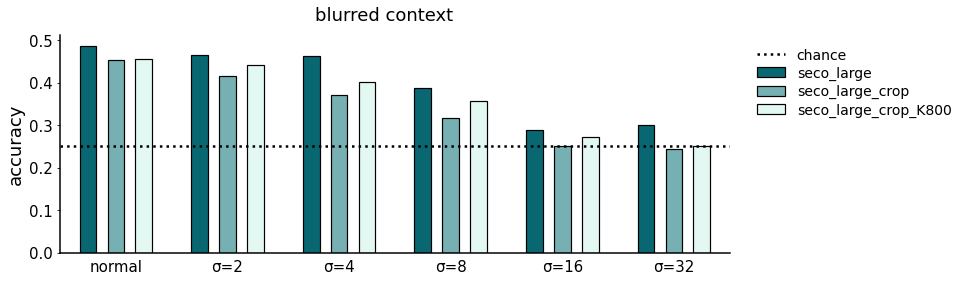

In [25]:
fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['blur{}'.format(i) for i in range(1,6)]
xtick_rename = ['normal'] + ['σ={}'.format(_) for _ in [2,4,8,16,32]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*(N+1)+_ for _ in range(N)])
    xtick_ori.append(i*(N+1)+N/2-0.5)
    colors.extend(["#096771","#76B0B2","#E3F8F3","#A79277","#D1BB9E","#EAD8C0"][:N])
    labels.extend(model_names)
    
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('blurred context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:N],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.35,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)


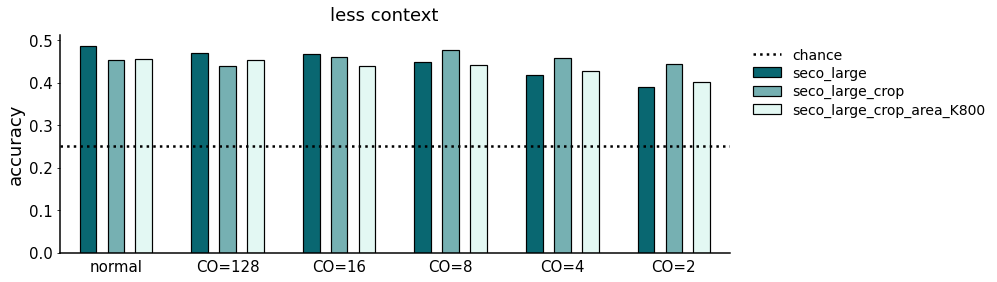

In [18]:
fig, ax = plt.subplots(1, 1,figsize=(12,4))
conditions = ['normal']+['amount{}'.format(i) for i in range(5,0,-1)]
xtick_rename = ['normal'] + ['CO={}'.format(_) for _ in [128,16,8,4,2]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
# brown A79277 D1BB9E EAD8C0 FFF2E1
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*(N+1)+_ for _ in range(N)])
    xtick_ori.append(i*(N+1)+N/2-0.5)
    colors.extend(["#096771","#76B0B2","#E3F8F3","#A79277","#D1BB9E","#EAD8C0"][:N])
    labels.extend(model_names)
    
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('less context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:N],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.4,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)


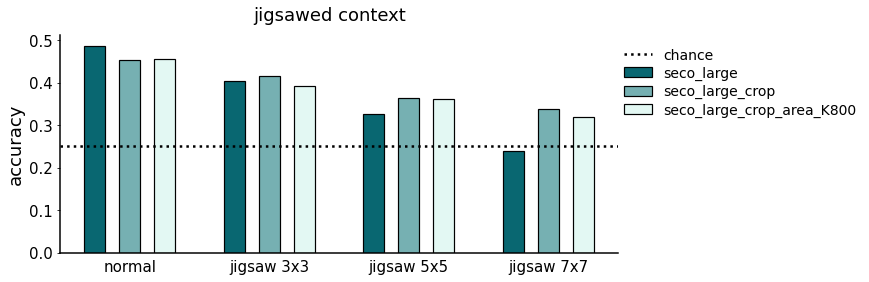

In [22]:
fig, ax = plt.subplots(1, 1,figsize=(10,4))
conditions = ['normal']+['jigsaw{}'.format(i) for i in range(1,4)]
xtick_rename = ['normal'] + ['jigsaw {}x{}'.format(_,_) for _ in [3,5,7]]
palette = ['#{}'.format(_) for _ in ["096771","408B92","76B0B2","ADD4D3","E3F8F3"]]
xtick_ori, xs, ys, colors, labels = [], [], [], [], []
for i, cond in enumerate(conditions):
    for model in model_names:
        ys.append(model_results_avg[model][cond])
    xs.extend([i*(N+1)+_ for _ in range(N)])
    xtick_ori.append(i*(N+1)+N/2-0.5)
    colors.extend(["#096771","#76B0B2","#E3F8F3","#A79277","#D1BB9E","#EAD8C0"][:N])
    labels.extend(model_names)
plt.plot([-1]+xs+[xs[-1]+1], [0.25]*(len(xs)+2),label='chance',ls=':',color='black',linewidth=2.5)
bars =plt.bar(xs,ys, width=0.6,linewidth=1.2,edgecolor='black',color=colors, label=labels)
plt.suptitle('jigsawed context'.format(0), fontsize=18)

# plt.xlabel('mode', fontsize=18)
plt.ylabel('accuracy', fontsize=18)
plt.xticks(xtick_ori,xtick_rename,fontsize=15)
plt.yticks(fontsize=15)
plt.legend(["chance"]+labels[:N],loc='upper right',ncols=1,bbox_to_anchor=(0,0,1.45,1),prop={'size': 14},frameon=False, columnspacing=0.8,labelspacing=0.3)
# ax.set_xticklabels(ys)
ax.set_xlim([-1, xs[-1]+1])
ax.xaxis.set_ticks_position('none') 
ax.spines[['right', 'top']].set_visible(False)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)
